
# Anomaly Detection

## What is an Anomaly?

An anomaly (or outlier) is a data point that differs significantly from the majority of the data.

-   **In Finance**: A $10,000 credit card transaction at 3 AM.
-   **In Security**: A user logging in from three different countries in one hour.
-   **In Manufacturing**: A machine vibrating at a slightly different frequency than usual.

Detecting these rare events is critical because they often represent high-risk or high-value incidents.

## Types of Detection

1.  **Supervised**: We have a dataset with labels ("Fraud", "Normal"). This is just standard Classification (usually with imbalanced data).
2.  **Unsupervised**: We have no labels. We assume the majority of data is "Normal" and look for points that are statistically far from the rest.
3.  **Semi-Supervised**: We train only on "Normal" data. Anything that looks different from the training set is flagged as an anomaly.

## Techniques Overview

| Method             | Description                          | Best For                    |
|------------------ |------------------------------------ |--------------------------- |
| **Statistical**    | Z-Scores, Interquartile Range (IQR). | Simple, univariate data.    |
| **Distance-Based** | k-Nearest Neighbors (k-NN), k-Means. | Clusters of normal data.    |
| **Density-Based**  | DBSCAN, Isolation Forest.            | Complex, non-linear shapes. |

## Evaluation Metrics

Evaluating anomaly detection models can be challenging due to imbalanced data. Common metrics include:

-   **Precision**: The proportion of true anomalies among the detected anomalies.
-   **Recall**: The proportion of true anomalies that were correctly detected.
-   **F1 Score**: The harmonic mean of precision and recall.
-   **Confusion Matrix**: Shows true/false positives and negatives at a glance.

## Practical Demonstration: Unsupervised Detection

We will generate a dataset containing distinct clusters of normal data and then sprinkle in some random noise (anomalies). We will try to find the noise without being told which points are which.

### Generate Synthetic Data

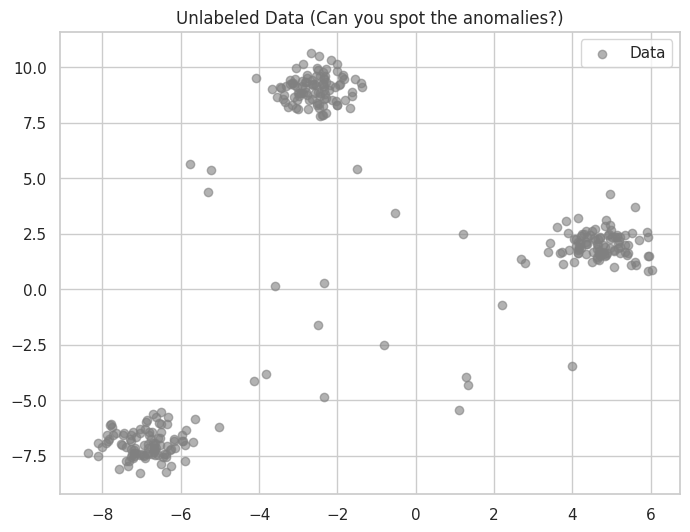

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

sns.set_theme(style="whitegrid")
np.random.seed(42)

# 1. Generate Normal Data (3 blobs)
X_normal, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=42)

# 2. Generate Anomalies (Uniform noise)
X_anomalies = np.random.uniform(low=-6, high=6, size=(20, 2))

# Combine
X = np.vstack([X_normal, X_anomalies])

# Construct True Labels for later evaluation: Normal=0, Anomaly=1
y_true = np.array([0] * 300 + [1] * 20)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], color='grey', alpha=0.6, label='Data')
plt.title("Unlabeled Data (Can you spot the anomalies?)")
plt.legend()
plt.show()

### Method 1: k-Means (Distance Based)

k-Means assumes anomalies are points that are **far away from any cluster center**.

1.  Fit k-Means to the data.
2.  Calculate the distance of each point to its nearest centroid.
3.  Points with large distances are anomalies.

In [2]:
from sklearn.cluster import KMeans

# Fit k-Means (assuming we guess 3 clusters correctly)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X)

# Calculate distances to assigned cluster center
# transform() returns distance to ALL centroids; min(axis=1) gets the nearest one
distances = np.min(kmeans.transform(X), axis=1)

# Define threshold (e.g., 95th percentile)
threshold = np.percentile(distances, 95)

# Predict: True = Anomaly
anomalies_kmeans = distances > threshold

print(f"Threshold Distance: {threshold:.2f}")
print(f"Anomalies Detected: {np.sum(anomalies_kmeans)}")

Threshold Distance: 3.28
Anomalies Detected: 16


### Visualizing k-Means Results

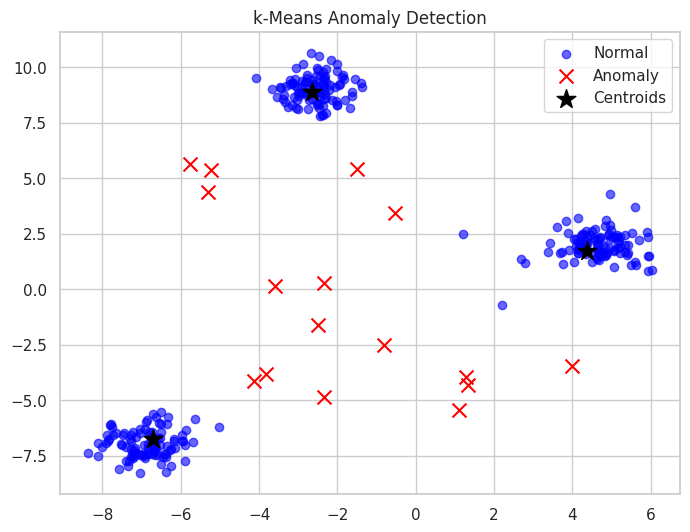

In [3]:
plt.figure(figsize=(8, 6))

# Plot Normal
plt.scatter(X[~anomalies_kmeans, 0], X[~anomalies_kmeans, 1], c='blue', alpha=0.6, label='Normal')

# Plot Anomalies
plt.scatter(X[anomalies_kmeans, 0], X[anomalies_kmeans, 1], c='red', marker='x', s=100, label='Anomaly')

# Plot Centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', s=200, marker='*', label='Centroids')

plt.title("k-Means Anomaly Detection")
plt.legend()
plt.show()

### Method 2: DBSCAN (Density Based)

DBSCAN clusters data based on density. Points that do not find enough neighbors within a radius `eps` are explicitly labeled as **Noise (-1)**. This is often superior to k-Means because we don't need to pick a threshold manually.

In [4]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# DBSCAN is sensitive to scale
X_scaled = StandardScaler().fit_transform(X)

# eps=0.5 (radius), min_samples=5 (neighbors required to be a core point)
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# DBSCAN labels noise as -1
anomalies_dbscan = (labels == -1)

print(f"Anomalies Detected by DBSCAN: {np.sum(anomalies_dbscan)}")

Anomalies Detected by DBSCAN: 7


### Visualizing DBSCAN Results

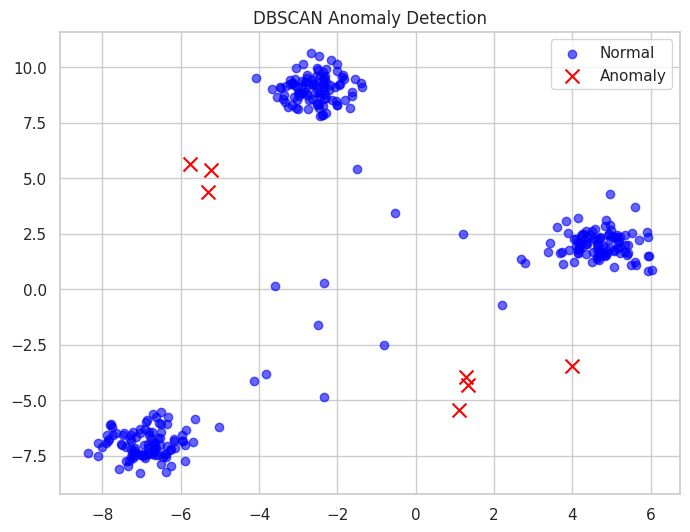

In [5]:
plt.figure(figsize=(8, 6))

# Plot Normal (labels != -1)
plt.scatter(X[~anomalies_dbscan, 0], X[~anomalies_dbscan, 1], c='blue', alpha=0.6, label='Normal')

# Plot Anomalies (labels == -1)
plt.scatter(X[anomalies_dbscan, 0], X[anomalies_dbscan, 1], c='red', marker='x', s=100, label='Anomaly')

plt.title("DBSCAN Anomaly Detection")
plt.legend()
plt.show()

## Evaluation (When Truth is Known)

In the real world, you rarely have labels. But for testing, we created the data, so we know the truth. Let's verify our accuracy.

--- DBSCAN Performance ---
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98       300
     Anomaly       1.00      0.35      0.52        20

    accuracy                           0.96       320
   macro avg       0.98      0.68      0.75       320
weighted avg       0.96      0.96      0.95       320



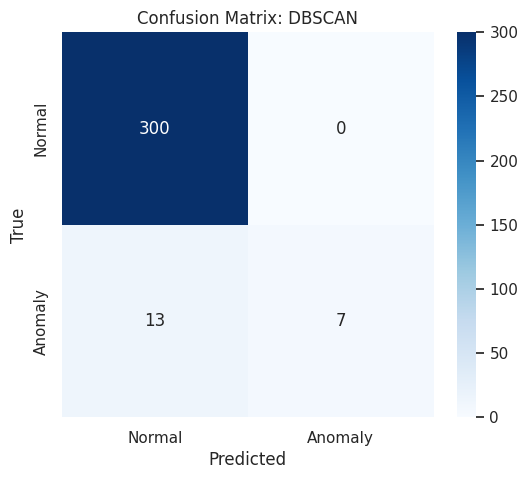

In [6]:
from sklearn.metrics import classification_report, confusion_matrix

print("--- DBSCAN Performance ---")
# Convert boolean to int (False->0, True->1)
print(classification_report(y_true, anomalies_dbscan.astype(int), target_names=['Normal', 'Anomaly']))

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true, anomalies_dbscan.astype(int)), annot=True, fmt='d',
            xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"],
            cmap="Blues")
plt.title("Confusion Matrix: DBSCAN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Exercises

### Isolation Forest

**Isolation Forest** is the industry standard for high-dimensional anomaly detection. It works by randomly slicing the data; anomalies are easier to isolate (require fewer cuts) than normal points clustered together.

-   Use `sklearn.ensemble.IsolationForest`.
-   Fit it to the synthetic data `X`.
-   **Note**: Isolation Forest returns -1 for anomalies and 1 for normal.

In [7]:
from sklearn.ensemble import IsolationForest

# contamination='auto' lets the model guess the % of anomalies
# You can set contamination=0.06 (since we have ~6% anomalies) if you know it
iso_forest = IsolationForest(contamination=0.06, random_state=42)
preds_iso = iso_forest.fit_predict(X)

# Convert to boolean mask (True if anomaly)
mask_iso = preds_iso == -1

print(f"Isolation Forest detected {sum(mask_iso)} anomalies.")

Isolation Forest detected 20 anomalies.


### Visualization

-   Plot the results of the Isolation Forest. Compare it mentally to DBSCAN.

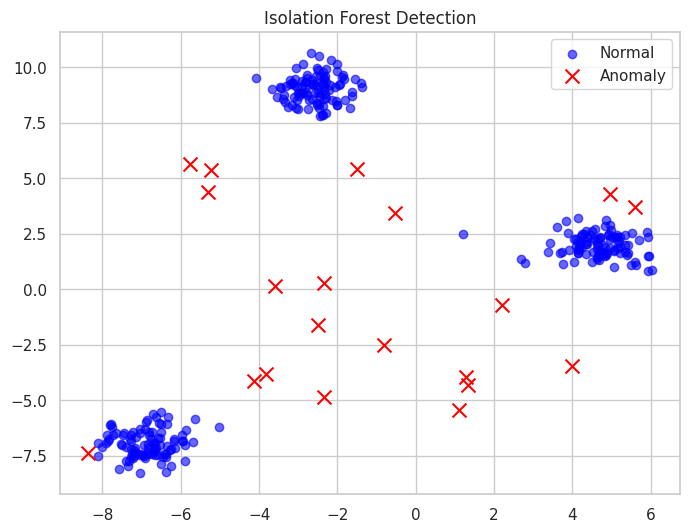

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(X[~mask_iso, 0], X[~mask_iso, 1], c='blue', alpha=0.6, label='Normal')
plt.scatter(X[mask_iso, 0], X[mask_iso, 1], c='red', marker='x', s=100, label='Anomaly')
plt.title("Isolation Forest Detection")
plt.legend()
plt.show()

### The "Swamping" Effect

Add a **dense** cluster of anomalies (instead of scattered noise) to the data and see if k-Means can detect them.

-   **Hint**: k-Means might just think the dense anomaly cluster is a valid new cluster! This is a common failure mode.

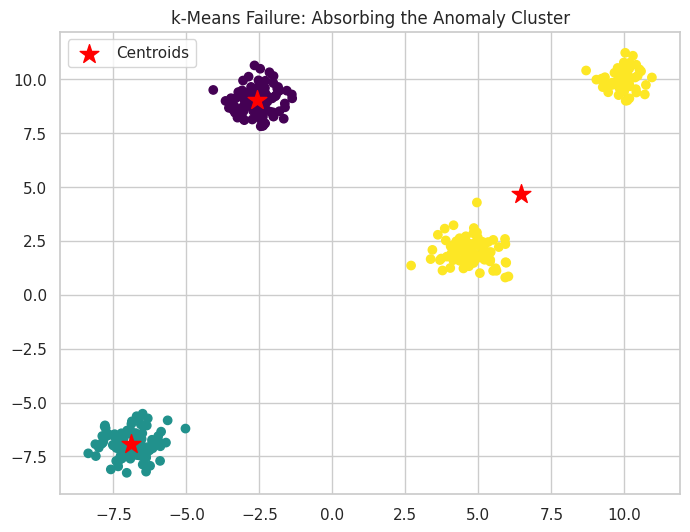

In [9]:
# Add a dense cluster of 50 points far away
X_dense_anomaly, _ = make_blobs(n_samples=50, centers=[[10, 10]], cluster_std=0.5)
X_new = np.vstack([X_normal, X_dense_anomaly])

# Fit k-Means with k=3 (assuming we still think there are only 3 normal groups)
km_fail = KMeans(n_clusters=3, random_state=42, n_init='auto').fit(X_new)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X_new[:, 0], X_new[:, 1], c=km_fail.labels_, cmap='viridis')
plt.scatter(km_fail.cluster_centers_[:, 0], km_fail.cluster_centers_[:, 1], c='red', marker='*', s=200, label='Centroids')
plt.title("k-Means Failure: Absorbing the Anomaly Cluster")
plt.legend()
plt.show()

## Summary

1.  **k-Means**: Simple, but requires setting a manual distance threshold. Fails if anomalies form clusters.
2.  **DBSCAN**: Excellent for spatial data. Automatically finds "Noise" based on low density.
3.  **Isolation Forest**: Powerful, modern standard for higher dimensional data.